# Closed-Loop Gain Recovery Test

Synthetic closed-loop demonstration of the `newnucal` calibration pipeline:

1. Build a HERA-like array and a random chromatic sky model
2. Simulate visibilities with `ForwardModel` at several times (Earth rotation) and frequencies
3. Apply known per-frequency gain degeneracies (amplitude, phase, phase gradient)
4. Recover gains with the sky held fixed — verifying the solution reproduces the data
5. Show joint sky + gain recovery starting from a perturbed sky

The key physics being tested: the DPSS spectral constraints on the sky/beam model, combined with Earth rotation that decorrelates sky pixels from beam pixels across time, provide enough information to reduce the residuals.  Note that the recovered gains need not match the injected ones exactly — there are residual degeneracies — but the calibrated model visibilities should match the data.

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from astropy.time import Time
from astropy.coordinates import EarthLocation
import healpy

jax.config.update("jax_enable_x64", False)  # float32 throughout

from newnucal import HERAArray, BeamModel, ForwardModel, Calibrator, apply_gains, init_gain_params
from newnucal.dpss import dpss_matrix
from newnucal.simulate import compute_rotation_matrices

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110})

basis_vector_type was not defined, defaulting to azimuth and zenith_angle.
pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


## 1. Array, frequency, and time setup

In [2]:

# --- Array ---
array = HERAArray.from_hex(hexnum=4, sep=14.6)
print(f"Antennas: {array.nants},  Baselines: {array.nbls}")

# --- Frequencies ---
nfreq = 32
freqs = np.linspace(50e6, 225e6, nfreq)  # Hz

# --- Times ---
from astropy.time import Time
import astropy.units as u

hera_loc = EarthLocation(lat=-30.7215 * u.deg, lon=21.4283 * u.deg, height=1073.0 * u.m)
t0 = Time("2023-03-21T04:00:00", scale="utc")
ntime = 8
dt = 60  * u.min / ntime
times = t0 + np.arange(ntime) * dt
print(f"Times: {ntime},  span: {(times[-1] - times[0]).to(u.min):.1f}")

# --- Rotation matrices ---
from newnucal.simulate import compute_rotation_matrices
rot_matrices = compute_rotation_matrices(times, hera_loc)
print(f"rot_matrices shape: {rot_matrices.shape}")


Antennas: 33,  Baselines: 130
Times: 8,  span: 52.5 min
rot_matrices shape: (8, 3, 3)


## 2. Beam and sky model

In [3]:
sky_nside = 32
beam_nside = 16

# Beam: Airy disk (HERA dish diameter 14.6 m), DPSS eta_max = 20 ns
beam_model = BeamModel(nside=beam_nside, freqs=freqs, eta_max=20e-9)
print(f"Beam DPSS modes: {beam_model.A_beam.shape[1]}")

# Sky: random power-law HEALPix map
npix_sky = healpy.nside2npix(sky_nside)
rng = np.random.default_rng(42)

# Build a smooth chromatic sky: per-pixel spectral index drawn from N(-0.7, 0.1)
ref_freq = 150e6
spectral_indices = rng.normal(-0.7, 0.1, npix_sky).astype(np.float32)
ref_flux = rng.exponential(scale=1.0, size=npix_sky).astype(np.float32)
# flux_true[npix, nfreq]
flux_true = ref_flux[:, None] * (freqs[None, :] / ref_freq) ** spectral_indices[:, None]

# Project onto sky DPSS basis
sky_eta_max = 40e-9  # ns — wider than beam because sky has steeper spectral structure
from newnucal.dpss import dpss_matrix, dpss_project
A_sky = dpss_matrix(freqs, sky_eta_max)
print(f"Sky DPSS modes: {A_sky.shape[1]}")

sky_coeffs_true = jnp.array(dpss_project(flux_true, A_sky), dtype=jnp.float32)
print(f"sky_coeffs_true shape: {sky_coeffs_true.shape}")


Beam DPSS modes: 14
Sky DPSS modes: 22
sky_coeffs_true shape: (12288, 22)


## 3. Simulate true visibilities and apply known gain perturbations

In [4]:
fwd = ForwardModel(array, sky_nside, beam_model, freqs, eps=1e-5)
fwd.set_sky_dpss(A_sky)

print("Simulating true visibilities (this compiles the JIT on first run)...")
vis_true = fwd.simulate(sky_coeffs_true, jnp.array(rot_matrices))
print(f"vis_true shape: {vis_true.shape},  dtype: {vis_true.dtype}")
print(f"Mean |vis|: {float(jnp.abs(vis_true).mean()):.4f}")

Simulating true visibilities (this compiles the JIT on first run)...
vis_true shape: (8, 32, 130),  dtype: complex64
Mean |vis|: 5.5593


In [5]:
# --- True gain perturbations (per time and frequency) ---
# Gains vary smoothly in both time and frequency, mimicking slow ionospheric drift.

t_norm = np.linspace(0, 1, ntime)[:, None]   # (ntime, 1)  — normalised time axis
f_norm = np.linspace(0, 1, nfreq)[None, :]   # (1, nfreq) — normalised frequency axis

# log_amp: ~5% amplitude variation across band, with ~2% slow drift in time
true_log_amp = (
    0.05 * np.cos(2 * np.pi * f_norm)
    + 0.02 * np.sin(2 * np.pi * t_norm)
).astype(np.float32)  # (ntime, nfreq)

# phase: smooth variation in frequency, slow drift in time
true_phase = (
    0.15 * np.sin(2 * np.pi * f_norm)
    + 0.05 * np.cos(2 * np.pi * t_norm)
).astype(np.float32)  # (ntime, nfreq)

# phi: small phase gradients with independent time and frequency variation
true_phi = np.zeros((ntime, 2, nfreq), dtype=np.float32)
true_phi[:, 0, :] = (                               # East
    1e-4 * np.cos(2 * np.pi * f_norm)
    + 3e-5 * np.sin(2 * np.pi * t_norm)
)
true_phi[:, 1, :] = (                               # North
    5e-5 * np.sin(2 * np.pi * f_norm)
    + 2e-5 * np.cos(2 * np.pi * t_norm)
)

true_log_amp_j = jnp.array(true_log_amp)
true_phase_j   = jnp.array(true_phase)
true_phi_j     = jnp.array(true_phi)

vis_data = apply_gains(vis_true, true_log_amp_j, true_phase_j, true_phi_j,
                       jnp.array(array.bls, dtype=jnp.float32))

print(f"vis_data shape: {vis_data.shape}")
print(f"log_amp RMS across times: {float(jnp.std(jnp.array(true_log_amp), axis=0).mean()):.4f}")
print(f"phi_E  RMS across times:  {float(jnp.std(jnp.array(true_phi[:, 0, :]), axis=0).mean()):.2e}")

vis_data shape: (8, 32, 130)
log_amp RMS across times: 0.0132
phi_E  RMS across times:  1.98e-05


## 4. Stage 1: Recover gains with sky held fixed (true sky)

With the sky fixed at truth, the gain-recovery problem looks nonlinear because gains enter the MSE loss as `exp(log_amp) * exp(i·(phase + phi@bl))`.  But it can be solved **exactly in one pass** via two linear steps:

1. **Matched-filter projection** (linear in the complex gain): for each (freq, baseline), the optimal unconstrained gain is `g[f,b] = Σ_t data·conj(model) / Σ_t |model|²`

2. **Log-domain linear regression** (linear in the 4 real parameters): `log g[f,b] = log_amp[f] + i·(phase[f] + phi_x[f]·bl_x[b] + phi_y[f]·bl_y[b])`, fit per frequency with weighted lstsq over baselines.

`Calibrator.fit_gains_linear` implements this.

In [6]:
cal = Calibrator(
    array=array,
    beam_model=beam_model,
    sky_nside=sky_nside,
    sky_eta_max=sky_eta_max,
    freqs=freqs,
    rot_matrices=rot_matrices,
    data=vis_data,
    eps=1e-5,
)

# init_params() now includes beam_coeffs alongside sky/gain parameters.
params0 = {
    "sky_coeffs":  sky_coeffs_true,
    "beam_coeffs": jnp.array(beam_model.coeffs, dtype=jnp.float32),
    **init_gain_params(ntime, nfreq),
}
loss_init = cal.calc_loss(params0)

# Analytic linear solve: fits gains independently at each time step.
# Step 1: per-time, per-baseline optimal gains via matched-filter projection.
# Step 2: log-domain weighted lstsq to fit (log_amp, phase, phi_x, phi_y)
#         per (time, freq) over baselines — vectorised, no Python loop.
#print("Fitting gains (analytic linear solve)...")
#gain_params_fit, loss_fit = cal.fit_gains_linear(sky_coeffs_true)
#
#print(f"Loss before: {loss_init:.4e}")
#print(f"Loss after:  {loss_fit:.4e}")
#print(f"Reduction:   {loss_init / loss_fit:.1f}x")
#print(f"gain shapes — log_amp: {gain_params_fit['log_amp'].shape}, "
#      f"phi: {gain_params_fit['phi'].shape}")

## 5. Data reproduction: baseline spectra and loss

In [7]:
freq_mhz = freqs / 1e6
t_show = 0
bls_j    = jnp.array(array.bls, dtype=jnp.float32)
beam_j   = jnp.array(beam_model.coeffs, dtype=jnp.float32)
bl_indices = [0, array.nbls // 4, array.nbls // 2, array.nbls - 1]

#params_before = {"sky_coeffs": sky_coeffs_true, "beam_coeffs": beam_j, **init_gain_params(ntime, nfreq)}
#params_after  = {"sky_coeffs": sky_coeffs_true, "beam_coeffs": beam_j, **gain_params_fit}
#vis_before = cal.simulate(params_before)
#vis_after  = cal.simulate(params_after)
#
## --- Gain recovery: plot mean over time with per-time envelope ---
#fig, axes = plt.subplots(2, 2, figsize=(11, 6))
#fig.suptitle("Stage 1: Recovered vs true gains  (analytic linear solve)\n"
#             "Solid = time-mean, shaded = ±1 time-std", fontsize=12)
#
#gain_panels = [
#    (axes[0, 0], gain_params_fit["log_amp"], true_log_amp, "log_amp"),
#    (axes[0, 1], gain_params_fit["phase"],   true_phase,   "phase (rad)"),
#    (axes[1, 0], gain_params_fit["phi"][:, 0, :], true_phi[:, 0, :], "phi_E (rad/m)"),
#    (axes[1, 1], gain_params_fit["phi"][:, 1, :], true_phi[:, 1, :], "phi_N (rad/m)"),
#]
#for ax, rec, true_val, ylabel in gain_panels:
#    rec = np.array(rec)
#    true_val = np.array(true_val)
#    rec_mean  = rec.mean(axis=0)
#    true_mean = true_val.mean(axis=0)
#    rec_std   = rec.std(axis=0)
#    ax.plot(freq_mhz, true_mean, "k-",  lw=2,   label="True (mean)")
#    ax.plot(freq_mhz, rec_mean,  "r--", lw=1.5, label="Recovered (mean)")
#    ax.fill_between(freq_mhz, rec_mean - rec_std, rec_mean + rec_std,
#                    color="r", alpha=0.2, label="Rec ±1 std (time)")
#    ax.set_ylabel(ylabel); ax.set_xlabel("Frequency (MHz)"); ax.legend(fontsize=7)
#
#plt.tight_layout(); plt.show()
#
#print("Gain recovery residuals (RMS over time and frequency):")
#for key, rec, true_j in [
#    ("log_amp", gain_params_fit["log_amp"], true_log_amp_j),
#    ("phase",   gain_params_fit["phase"],   true_phase_j),
#    ("phi_E",   gain_params_fit["phi"][:, 0, :], true_phi_j[:, 0, :]),
#    ("phi_N",   gain_params_fit["phi"][:, 1, :], true_phi_j[:, 1, :]),
#]:
#    rms = float(jnp.sqrt(jnp.mean((jnp.array(rec) - jnp.array(true_j))**2)))
#    print(f"  {key}: {rms:.2e}")
#
## --- Baseline spectra ---
#
#fig, axes = plt.subplots(len(bl_indices), 2, figsize=(12, 2.8 * len(bl_indices)), sharex=True)
#fig.suptitle(
#    f"Stage 1: Baseline spectra (t={t_show})  —  loss {loss_init:.2e} → {loss_fit:.2e}",
#    fontsize=11,
#)
#for row, bi in enumerate(bl_indices):
#    bl_len = float(jnp.linalg.norm(bls_j[bi, :2]))
#
#    ax = axes[row, 0]
#    ax.semilogy(freq_mhz, jnp.abs(vis_data)[t_show, :, bi],   "k-",  lw=1.5, label="Data")
#    ax.semilogy(freq_mhz, jnp.abs(vis_data - vis_before)[t_show, :, bi], "b--", lw=1,   label="Before", alpha=0.7)
#    ax.semilogy(freq_mhz, jnp.abs(vis_data - vis_after)[t_show, :, bi],  "r--", lw=1.5, label="After")
#    ax.set_ylabel(f"bl {bi} ({bl_len:.0f}m)\n|V|")
#    if row == 0: ax.legend(fontsize=8)
#    if row == len(bl_indices) - 1: ax.set_xlabel("Frequency (MHz)")
#
#    ax = axes[row, 1]
#    ax.plot(freq_mhz, jnp.angle(vis_data)[t_show, :, bi],   "k-",  lw=1.5, label="Data")
#    ax.plot(freq_mhz, jnp.angle(vis_before)[t_show, :, bi], "b--", lw=1,   label="Before", alpha=0.7)
#    ax.plot(freq_mhz, jnp.angle(vis_after)[t_show, :, bi],  "r--", lw=1.5, label="After")
#    ax.set_ylabel(f"bl {bi} ({bl_len:.0f}m)\narg(V) (rad)")
#    if row == 0: ax.legend(fontsize=8)
#    if row == len(bl_indices) - 1: ax.set_xlabel("Frequency (MHz)")
#
#plt.tight_layout(); plt.show()

## 6. Stage 2: Joint sky + gain + beam recovery (perturbed start)

Start the sky from a perturbed version of the truth (30% Gaussian noise on DPSS coefficients) and the beam from a perturbed version (10% noise). Jointly optimize sky, gains, and beam using `fit_alternating_dirty` with `solve_every` scheduling. This tests whether Earth rotation + DPSS spectral constraints are sufficient to disentangle all three components.

In [8]:
rng2 = np.random.default_rng(99)
sky_coeffs_perturbed = sky_coeffs_true + 0.30 * jnp.array(
    rng2.standard_normal(sky_coeffs_true.shape).astype(np.float32)
) * float(jnp.abs(sky_coeffs_true).mean())

# Perturb the beam coefficients by 10% Gaussian noise
beam_coeffs_true = jnp.array(beam_model.coeffs, dtype=jnp.float32)
rng3 = np.random.default_rng(77)
beam_coeffs_perturbed = beam_coeffs_true + 0.30 * jnp.array(
    rng3.standard_normal(beam_coeffs_true.shape).astype(np.float32)
) * float(jnp.abs(beam_coeffs_true).mean())

print(f"Sky perturbation RMS / signal RMS: "
      f"{float(jnp.std(sky_coeffs_perturbed - sky_coeffs_true)) / float(jnp.std(sky_coeffs_true)):.2f}")
print(f"Beam perturbation RMS / signal RMS: "
      f"{float(jnp.std(beam_coeffs_perturbed - beam_coeffs_true)) / float(jnp.std(beam_coeffs_true)):.2f}")

params_joint0 = {
    "sky_coeffs":  sky_coeffs_perturbed,
    "beam_coeffs": beam_coeffs_perturbed,
    **init_gain_params(ntime, nfreq),
}

Sky perturbation RMS / signal RMS: 0.18
Beam perturbation RMS / signal RMS: 0.05


In [9]:
params_joint, _ = cal.fit_alternating_dirty(
    params_joint0,
    n_iter=40,
    #sky_block_len=3,
    #beam_block_len=4,
    step_size=0.9,
    anderson_history=3,
    aa_start=1,
    beam_anderson_history=2,
    beam_aa_start=1,
    beam_aa_damping=0.5,
    beam_aa_ridge=1e-8,
    beam_aa_max_weight=10,
    #solve_every={'gains': 5, 'beam': 1, 'polish_beam': 5},
    solve_every={'gains': 10, 'beam': 1},
    beam_step_size=0.5,
    beam_polish_rel_tol=0.01,
    verbose=True,
)
#params_joint, _ = cal.fit_alternating_dirty(
#    params_joint0,
#    n_iter=4,
#    sky_block_len=4,
#    beam_block_len=4,
#    step_size=0.9,
#    anderson_history=3,
#    aa_start=1,
#    beam_anderson_history=2,
#    beam_aa_start=1,
#    beam_aa_damping=0.5,
#    beam_aa_ridge=1e-8,
#    beam_aa_max_weight=10,
#    solve_every={'gains': 4, 'beam': 1, 'polish_beam': 3},
#    beam_step_size=0.5,
#    verbose=True,
#)

    [gains 000]: loss=1.9559e+00  eff=3.70e-01 Δloss/s
  step 0000 [gains]: loss=1.9559e+00  eff[sky= N/A   beam= N/A   gains=3.70e-01]  t=4.2s
    [sky    000]: loss=1.3131e+00  eff=1.35e-01 Δloss/s
  step 0001 [sky  ]: loss=1.3131e+00  eff[sky=1.35e-01 beam= N/A   gains=3.70e-01]  t=9.0s
    [beam    000]: loss=1.2355e+00  eff=1.15e-02 Δloss/s
  step 0002 [beam ]: loss=1.2355e+00  eff[sky=1.35e-01 beam=1.15e-02 gains=3.70e-01]  t=15.7s
    [gains 001]: loss=1.2143e+00  eff=4.41e-03 Δloss/s
  step 0003 [gains]: loss=1.2143e+00  eff[sky=1.35e-01 beam=1.15e-02 gains=4.41e-03]  t=20.8s
    [sky AA 001]: loss=6.7302e-01  eff=5.35e-02 Δloss/s
  step 0004 [sky  ]: loss=6.7302e-01  eff[sky=1.02e-01 beam=1.15e-02 gains=4.41e-03]  t=30.9s
    [sky AA 002]: loss=3.3210e-01  eff=4.28e-02 Δloss/s
  step 0005 [sky  ]: loss=3.3210e-01  eff[sky=7.84e-02 beam=1.15e-02 gains=4.41e-03]  t=38.8s
    [sky AA 003]: loss=1.6008e-01  eff=2.25e-02 Δloss/s
  step 0006 [sky  ]: loss=1.6008e-01  eff[sky=5.60e-0

Stage 2 loss — before: 3.3282e+00   after: 8.6641e-03
  reduction: 384.1x


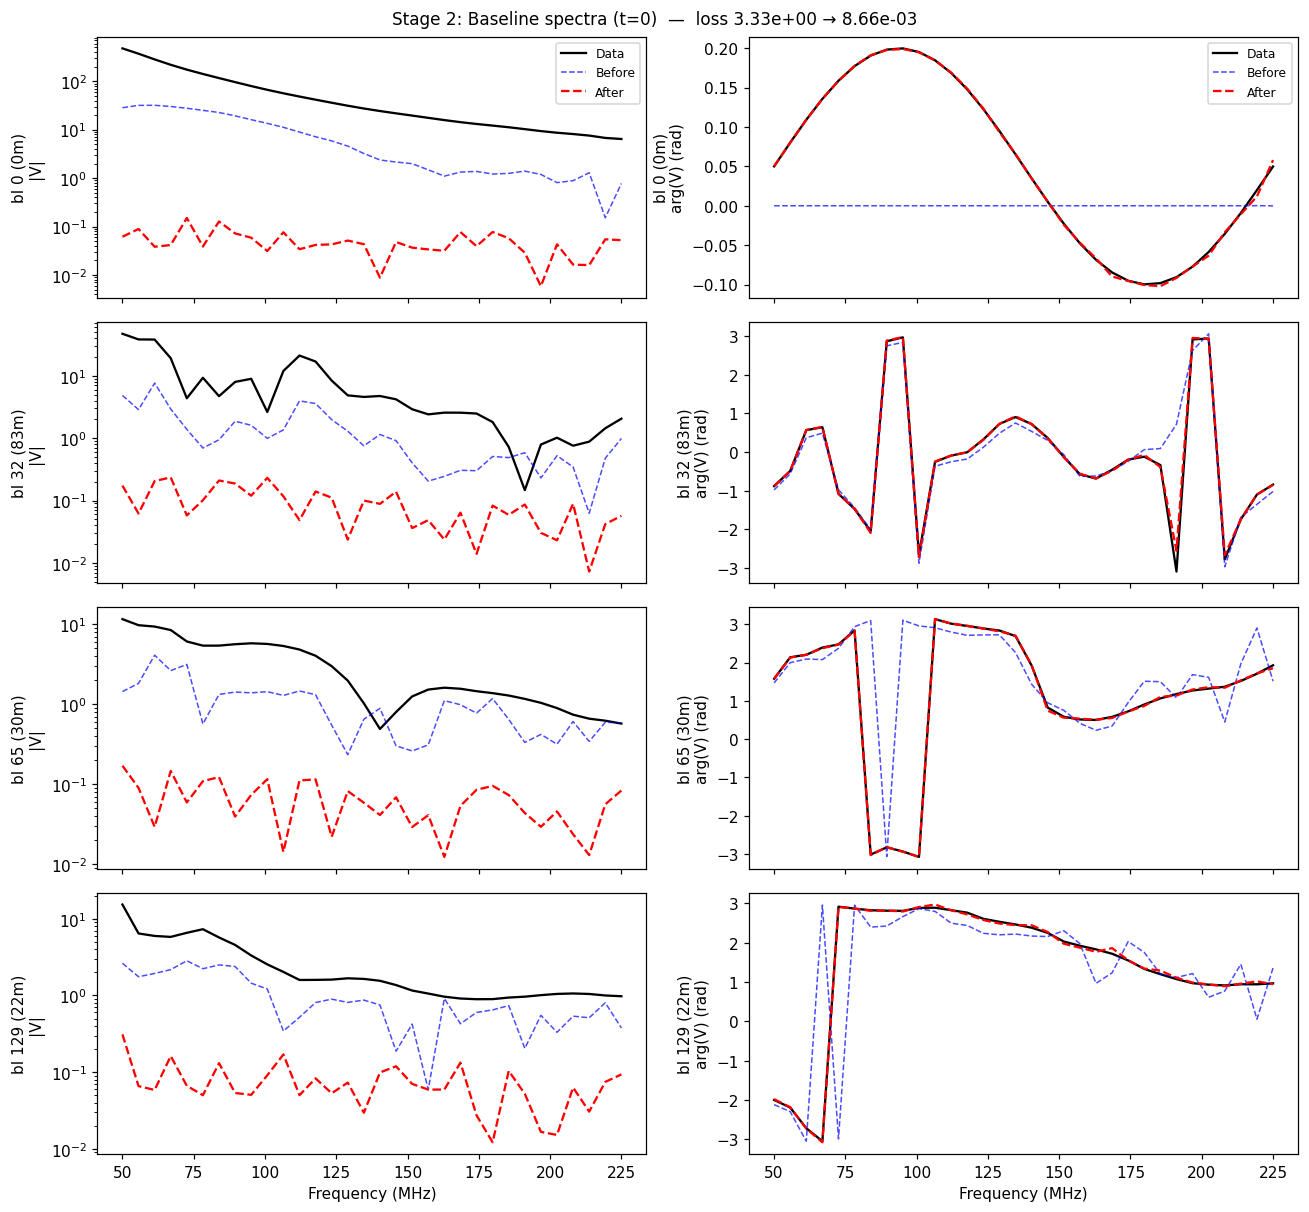

In [14]:

vis_joint_before = cal.simulate(params_joint0)
vis_joint_after  = cal.simulate(params_joint)

loss_joint_before = cal.calc_loss(params_joint0)
loss_joint_after  = cal.calc_loss(params_joint)
print(f"Stage 2 loss — before: {loss_joint_before:.4e}   after: {loss_joint_after:.4e}")
print(f"  reduction: {loss_joint_before / loss_joint_after:.1f}x")

fig, axes = plt.subplots(len(bl_indices), 2, figsize=(12, 2.8 * len(bl_indices)), sharex=True)
fig.suptitle(
    f"Stage 2: Baseline spectra (t={t_show})  —  loss {loss_joint_before:.2e} → {loss_joint_after:.2e}",
    fontsize=11,
)
for row, bi in enumerate(bl_indices):
    bl_len = float(jnp.linalg.norm(bls_j[bi, :2]))

    ax = axes[row, 0]
    ax.semilogy(freq_mhz, jnp.abs(vis_data)[t_show, :, bi],         "k-",  lw=1.5, label="Data")
    ax.semilogy(freq_mhz, jnp.abs(vis_data - vis_joint_before)[t_show, :, bi], "b--", lw=1,   label="Before", alpha=0.7)
    ax.semilogy(freq_mhz, jnp.abs(vis_data - vis_joint_after)[t_show, :, bi],  "r--", lw=1.5, label="After")
    ax.set_ylabel(f"bl {bi} ({bl_len:.0f}m)\n|V|")
    if row == 0: ax.legend(fontsize=8)
    if row == len(bl_indices) - 1: ax.set_xlabel("Frequency (MHz)")

    ax = axes[row, 1]
    ax.plot(freq_mhz, jnp.angle(vis_data)[t_show, :, bi],         "k-",  lw=1.5, label="Data")
    ax.plot(freq_mhz, jnp.angle(vis_joint_before)[t_show, :, bi], "b--", lw=1,   label="Before", alpha=0.7)
    ax.plot(freq_mhz, jnp.angle(vis_joint_after)[t_show, :, bi],  "r--", lw=1.5, label="After")
    ax.set_ylabel(f"bl {bi} ({bl_len:.0f}m)\narg(V) (rad)")
    if row == 0: ax.legend(fontsize=8)
    if row == len(bl_indices) - 1: ax.set_xlabel("Frequency (MHz)")

plt.tight_layout(); plt.show()


## 7. Recovered sky map

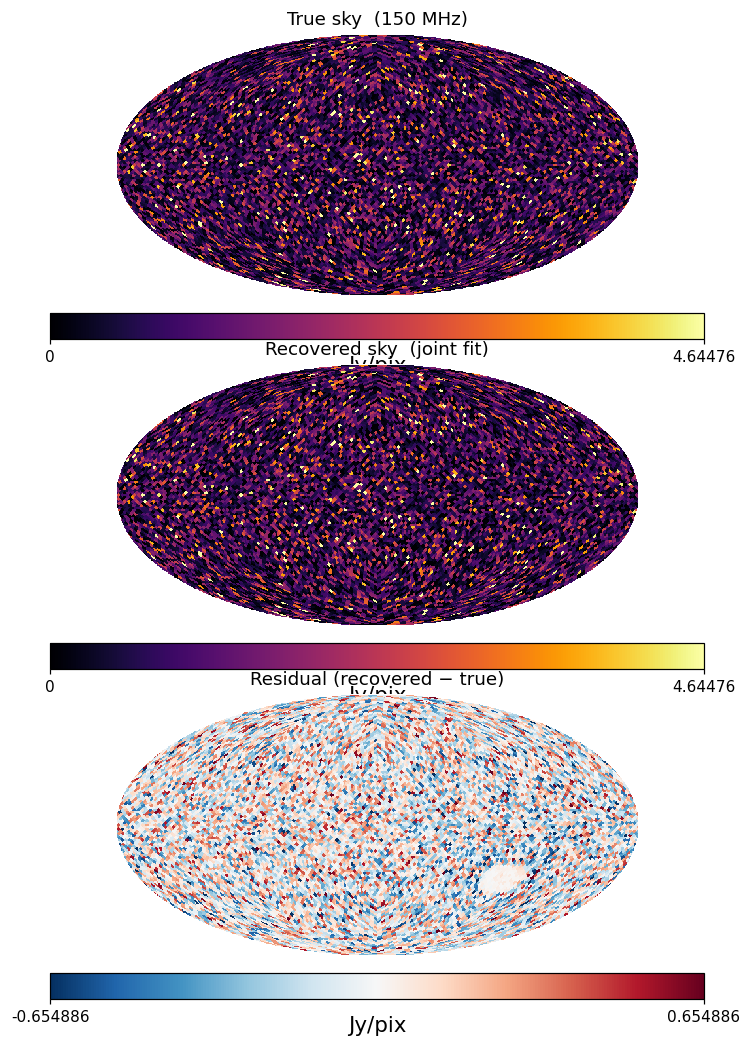

In [15]:

# Reconstruct sky flux from DPSS coefficients at a reference frequency
ifreq_ref = np.argmin(np.abs(freqs - ref_freq))

sky_true_map = np.array(flux_true[:, ifreq_ref])
sky_rec_map  = np.array(params_joint["sky_coeffs"] @ jnp.array(A_sky).T)[:, ifreq_ref]
sky_diff_map = sky_rec_map - sky_true_map

vmax = np.percentile(sky_true_map, 99)
vmin = 0.0

fig = plt.figure(figsize=(12, 9))
healpy.mollview(sky_true_map, fig=fig, sub=(3, 1, 1),
                title=f"True sky  ({ref_freq/1e6:.0f} MHz)", min=vmin, max=vmax,
                unit="Jy/pix", cmap="inferno")
healpy.mollview(sky_rec_map,  fig=fig, sub=(3, 1, 2),
                title="Recovered sky  (joint fit)", min=vmin, max=vmax,
                unit="Jy/pix", cmap="inferno")

diff_scale = np.percentile(np.abs(sky_diff_map), 99)
healpy.mollview(sky_diff_map, fig=fig, sub=(3, 1, 3),
                title="Residual (recovered − true)", min=-diff_scale, max=diff_scale,
                unit="Jy/pix", cmap="RdBu_r")
plt.show()

## 8. Recovered beam map and spectra

Beam RMS error — before: 2.7971e-03  after: 2.5177e-03  (signal: 5.8636e-02)
  relative: 0.048 → 0.043


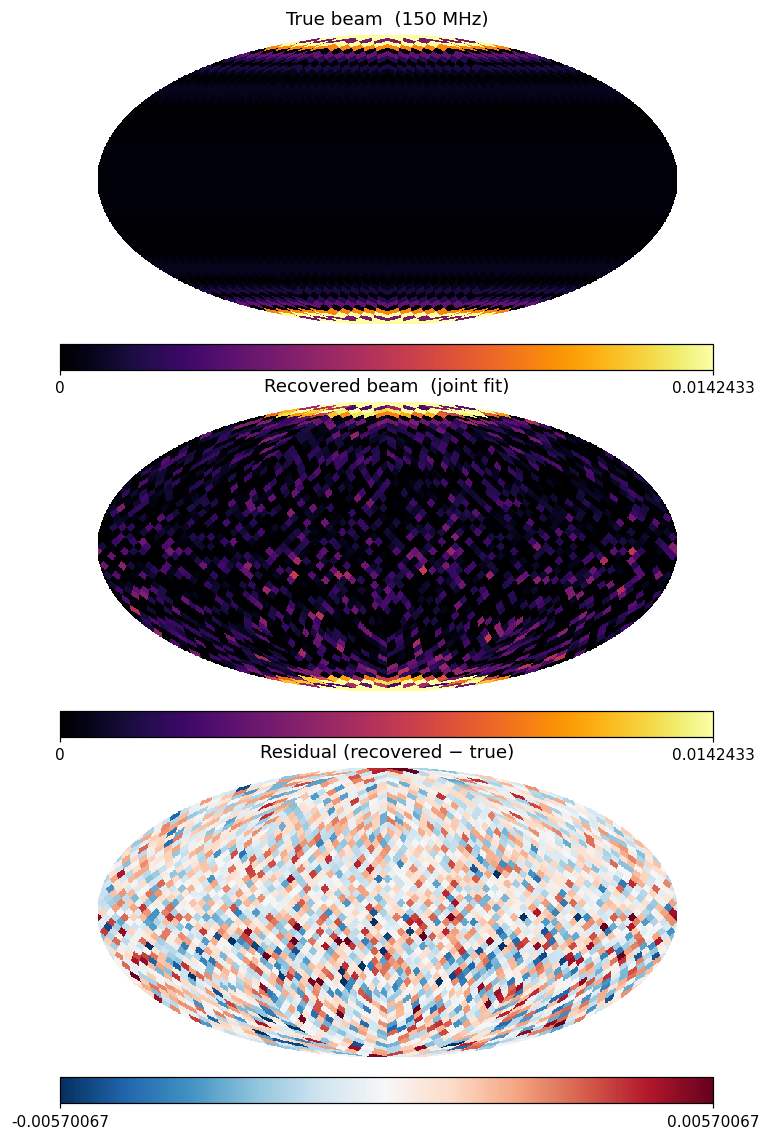

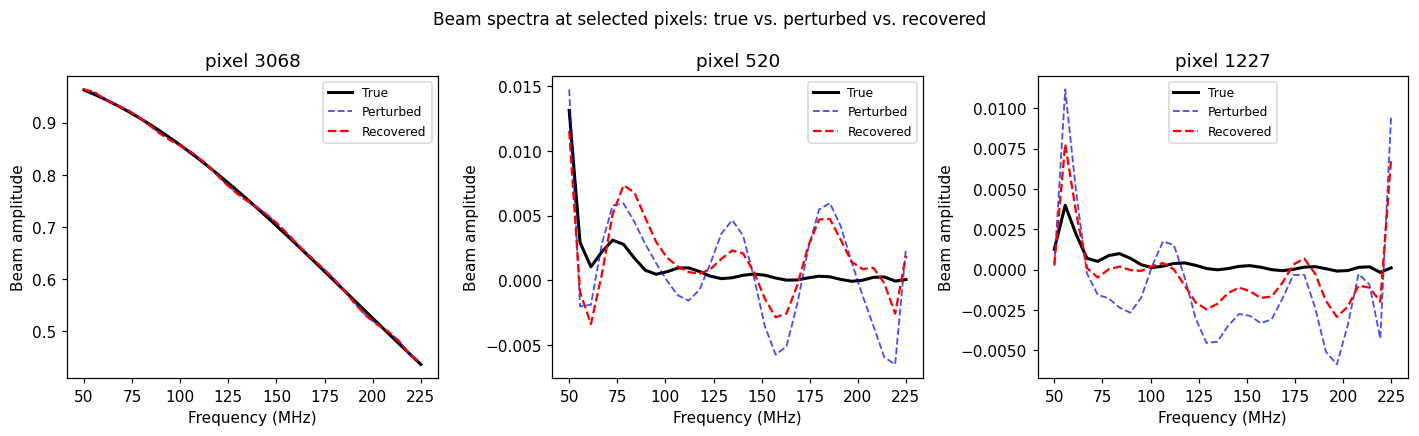

In [17]:
A_beam = jnp.array(beam_model.A_beam)   # (nfreq, nmodes_beam)

# Reconstruct beam spectra from DPSS coefficients: (npix_beam, nfreq)
beam_spec_true     = np.array(beam_coeffs_true     @ A_beam.T)
beam_spec_perturb  = np.array(beam_coeffs_perturbed @ A_beam.T)
beam_spec_rec      = np.array(params_joint["beam_coeffs"] @ A_beam.T)

rms_before = float(np.sqrt(np.mean((beam_spec_perturb - beam_spec_true) ** 2)))
rms_after  = float(np.sqrt(np.mean((beam_spec_rec     - beam_spec_true) ** 2)))
rms_signal = float(np.sqrt(np.mean(beam_spec_true ** 2)))
print(f"Beam RMS error — before: {rms_before:.4e}  after: {rms_after:.4e}  "
      f"(signal: {rms_signal:.4e})")
print(f"  relative: {rms_before/rms_signal:.3f} → {rms_after/rms_signal:.3f}")

# --- HEALPix maps at reference frequency ---
ifreq_ref = np.argmin(np.abs(freqs - ref_freq))

vmax_b = np.percentile(beam_spec_true[:, ifreq_ref], 99)

fig = plt.figure(figsize=(12, 10))
healpy.mollview(beam_spec_true[:, ifreq_ref],    fig=fig, sub=(3, 1, 1),
                title=f"True beam  ({ref_freq/1e6:.0f} MHz)",
                min=0, max=vmax_b, cmap="inferno")
healpy.mollview(beam_spec_rec[:, ifreq_ref],     fig=fig, sub=(3, 1, 2),
                title="Recovered beam  (joint fit)",
                min=0, max=vmax_b, cmap="inferno")
diff_b = beam_spec_rec[:, ifreq_ref] - beam_spec_true[:, ifreq_ref]
dscale = np.percentile(np.abs(diff_b), 99)
healpy.mollview(diff_b, fig=fig, sub=(3, 1, 3),
                title="Residual (recovered − true)",
                min=-dscale, max=dscale, cmap="RdBu_r")
plt.show()

# --- Spectra at the peak-beam pixel and a few others ---
peak_px = int(np.argmax(beam_spec_true[:, ifreq_ref]))
sample_pxs = [peak_px,
               int(np.argsort(beam_spec_true[:, ifreq_ref])[-beam_spec_true.shape[0]//4]),
               int(np.argsort(beam_spec_true[:, ifreq_ref])[-beam_spec_true.shape[0]//2])]

fig, axes = plt.subplots(1, len(sample_pxs), figsize=(13, 4), sharey=False)
fig.suptitle("Beam spectra at selected pixels: true vs. perturbed vs. recovered", fontsize=11)
for ax, px in zip(axes, sample_pxs):
    ax.plot(freq_mhz, beam_spec_true[px],    "k-",  lw=2,   label="True")
    ax.plot(freq_mhz, beam_spec_perturb[px], "b--", lw=1.2, label="Perturbed", alpha=0.7)
    ax.plot(freq_mhz, beam_spec_rec[px],     "r--", lw=1.5, label="Recovered")
    ax.set_title(f"pixel {px}")
    ax.set_xlabel("Frequency (MHz)")
    ax.set_ylabel("Beam amplitude")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()